In [1]:
#Import Libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#Load Dataset
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
#df.tail()

In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
#df.describe()

In [9]:
#Check Missing Values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
#Check Duplicate Rows
df.duplicated().sum()

np.int64(1)

In [12]:
#Remove Duplicates
df = df.drop_duplicates()

In [14]:
#df.duplicated().sum()

In [15]:
#Data Types
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [16]:
#Unique Values
for column in df.columns:
    print("="*50)
    print(column)
    print(df[column].unique())

age
[19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
sex
['female' 'male']
bmi
[27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.1
 23.75  28.975 31.35  33.915 28.785 28.3   37.4   17.765 34

In [17]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
#Label Encoding
encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(df["sex"])
df["smoker"] = encoder.fit_transform(df["smoker"])
df["region"] = encoder.fit_transform(df["region"])
encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(df["sex"])
df["smoker"] = encoder.fit_transform(df["smoker"])
df["region"] = encoder.fit_transform(df["region"])

In [20]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


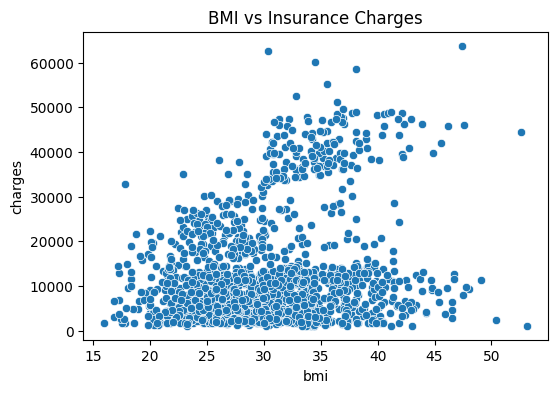

In [22]:
#Correlation Matrix
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

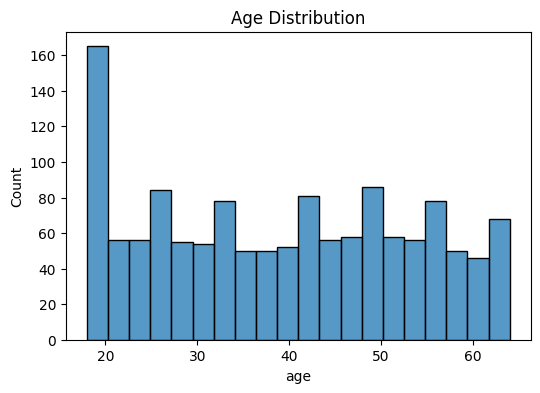

In [23]:
#Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20)
plt.title("Age Distribution")
plt.show()

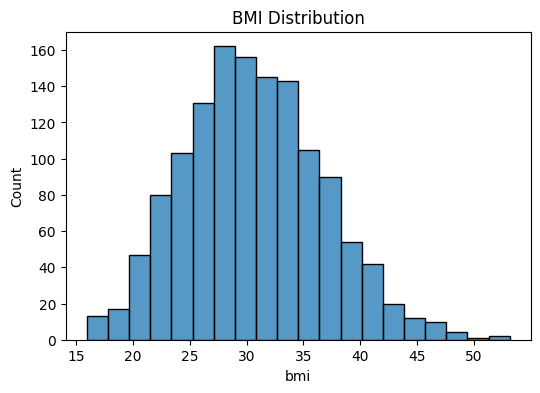

In [24]:
#BMI Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["bmi"], bins=20)
plt.title("BMI Distribution")
plt.show()

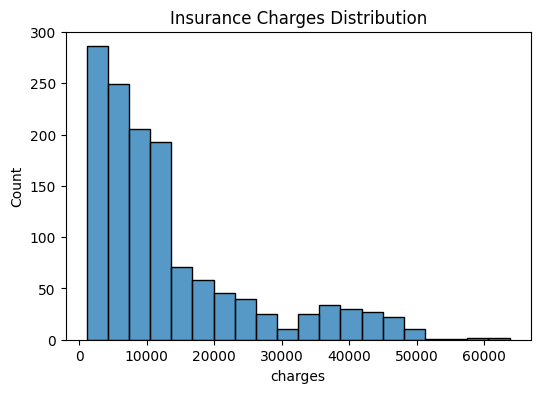

In [25]:
#Charges Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["charges"], bins=20)
plt.title("Insurance Charges Distribution")
plt.show()

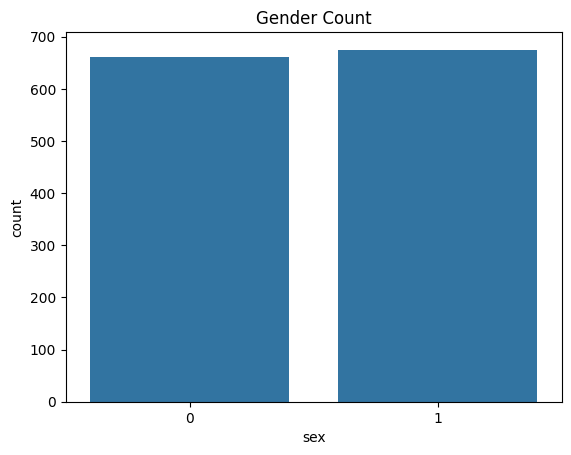

In [26]:
#Gender Count
sns.countplot(x="sex", data=df)
plt.title("Gender Count")
plt.show()

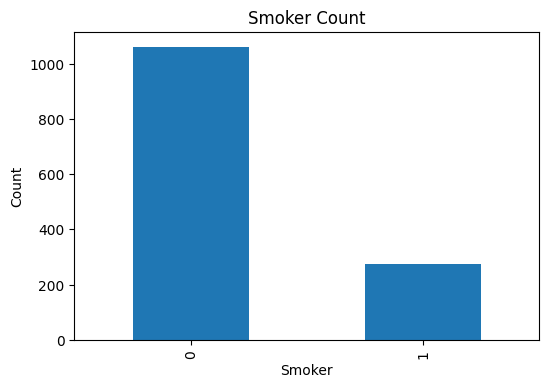

In [28]:
#Smoker Count
plt.figure(figsize=(6,4))

df['smoker'].value_counts().plot(kind='bar')

plt.title("Smoker Count")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.show()

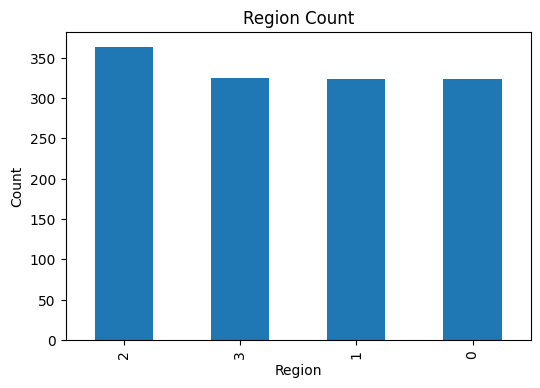

In [29]:
#region count
plt.figure(figsize=(6,4))

df['region'].value_counts().plot(kind='bar')

plt.title("Region Count")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

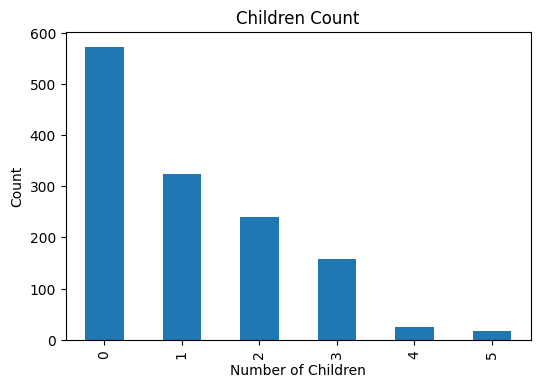

In [30]:
#chilndren count
plt.figure(figsize=(6,4))

df['children'].value_counts().sort_index().plot(kind='bar')

plt.title("Children Count")
plt.xlabel("Number of Children")
plt.ylabel("Count")
plt.show()

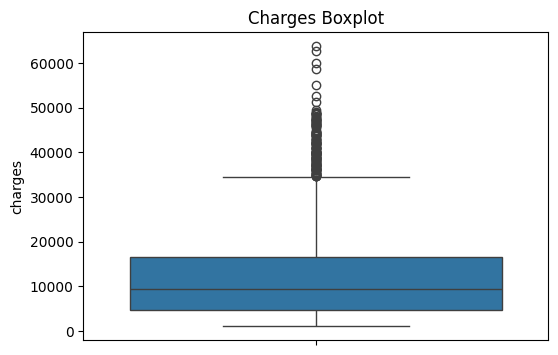

In [31]:
#Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(y=df["charges"])
plt.title("Charges Boxplot")
plt.show()

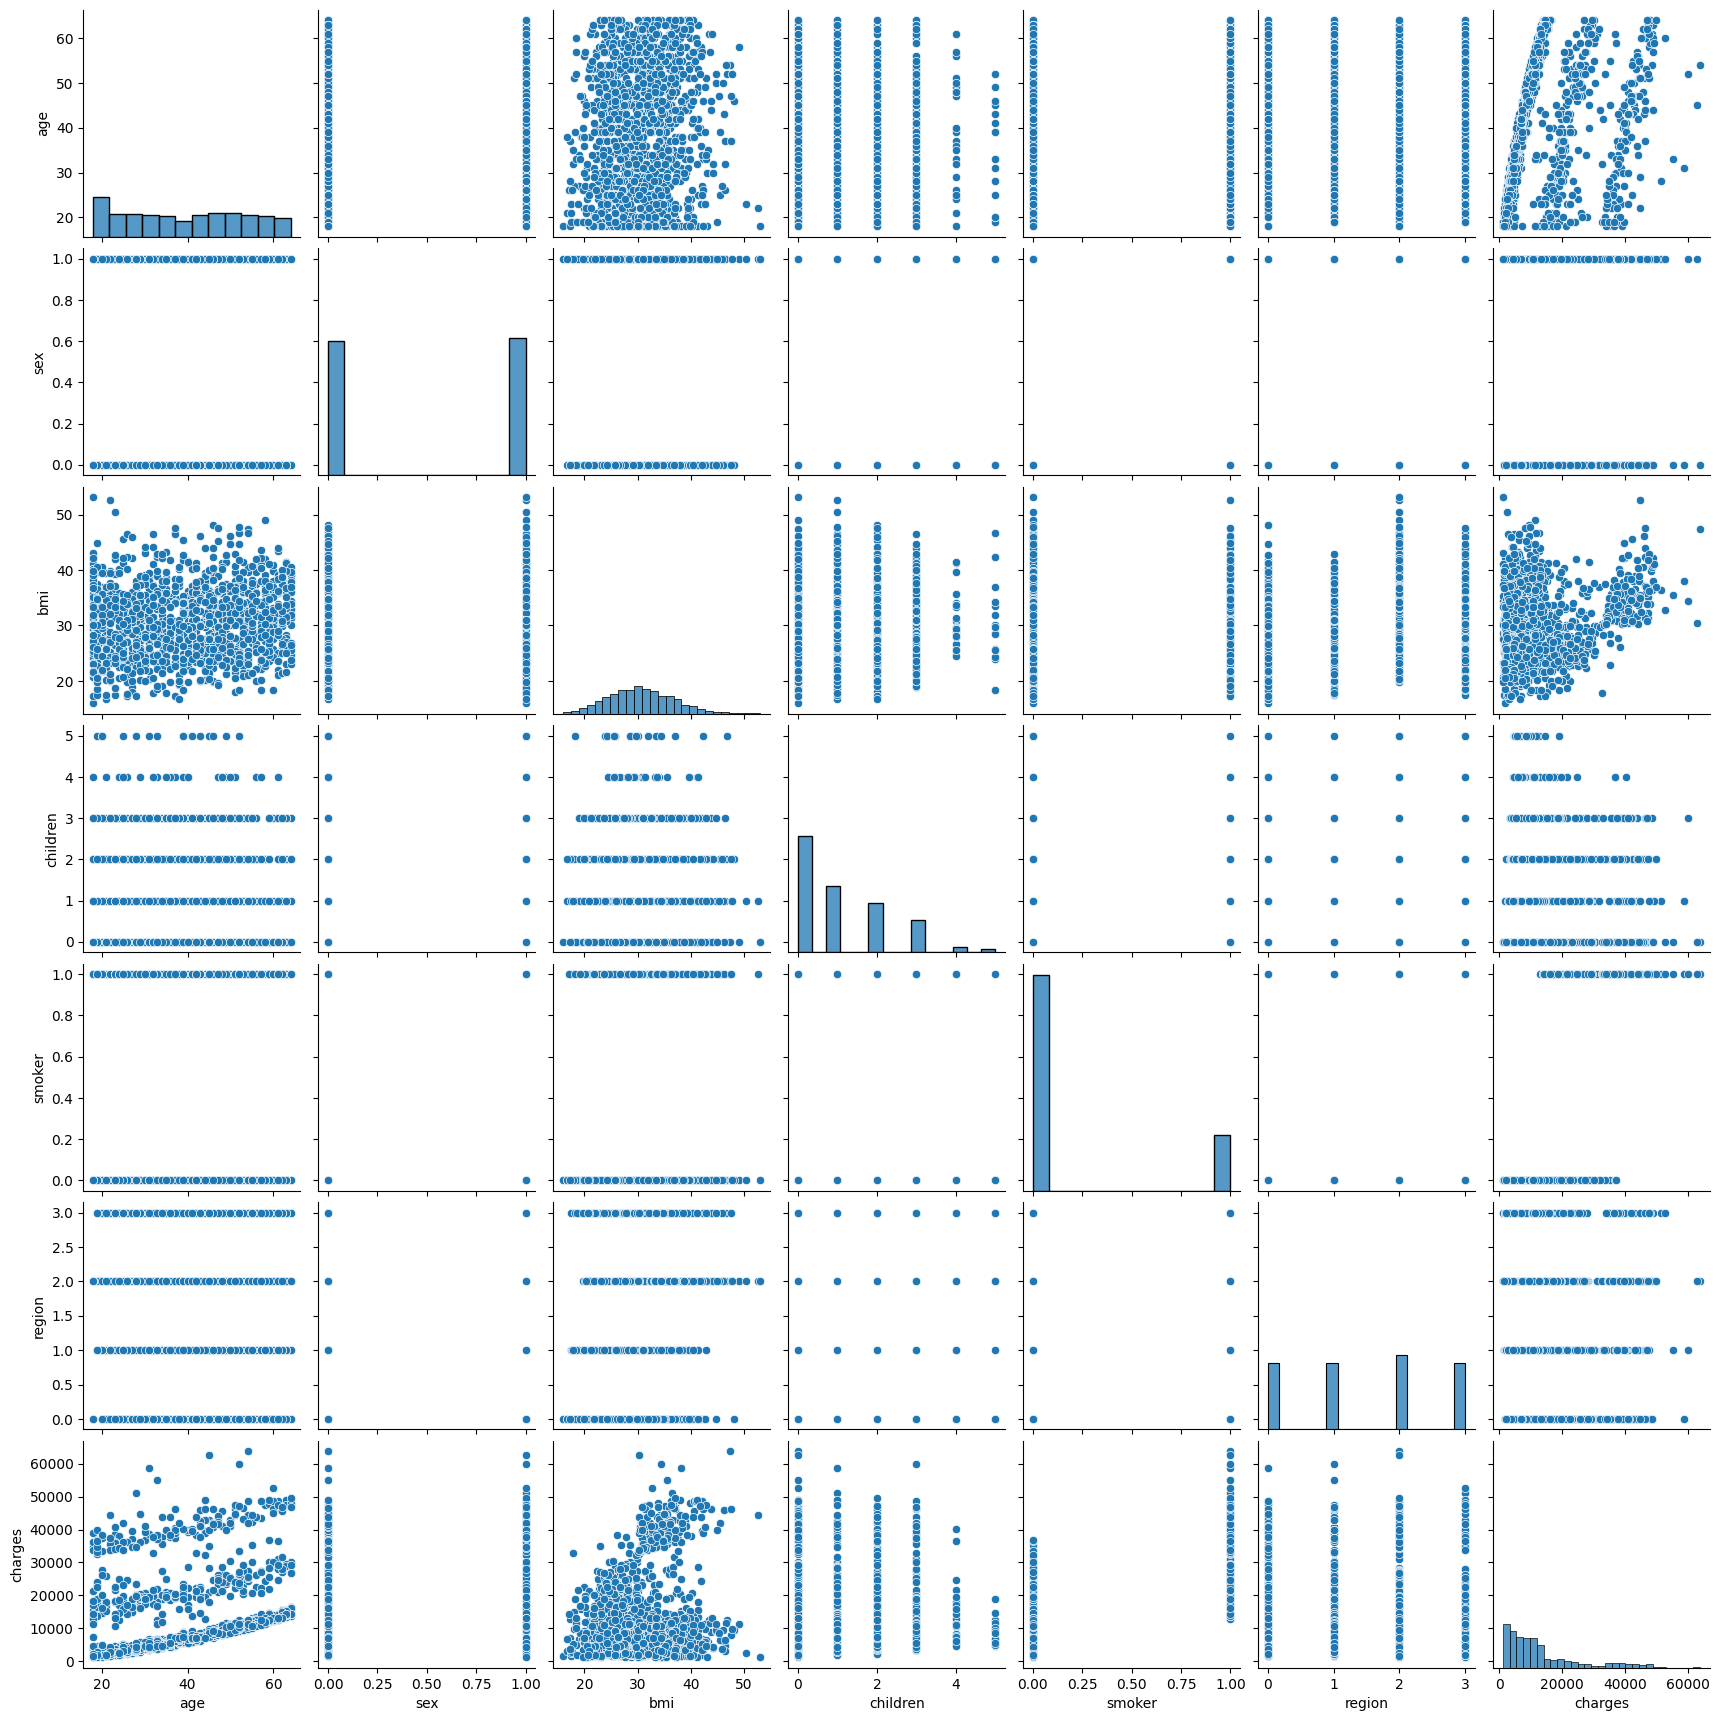

In [32]:
#Pairplot
sns.pairplot(df)
plt.show()

In [33]:
#Feature Selection
X = df.drop("charges", axis=1)
y = df["charges"]

In [34]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [35]:
#Train Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [37]:
#Prediction
y_pred = model.predict(X_test)

In [38]:
#MAE
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 4182.353155288297


In [39]:
#MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 35493102.61165053


In [40]:
#RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 5957.60879981646


In [41]:
#R² Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8068466322629111


In [42]:
#Actual vs Predicted
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(20)

,Actual,Predicted
900,8688.85885,8080.450186
1064,5708.86700,5592.871120
1256,11436.73815,14378.298655
298,38746.35510,31731.819541
237,4463.20510,9158.356944
481,9304.70190,13361.014269
240,38511.62830,30257.655258
277,2150.46900,1308.647356
415,7345.72660,10849.425445
707,10264.44210,11375.548519


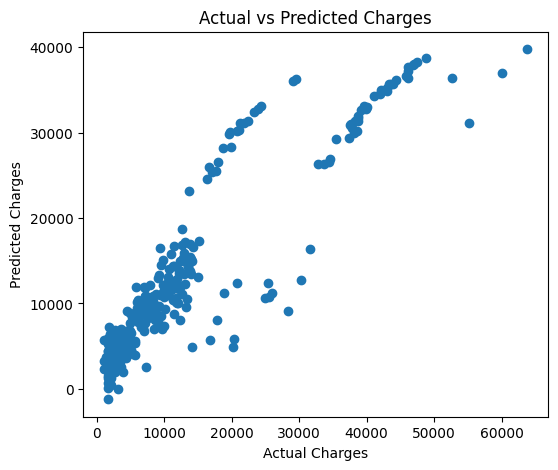

In [43]:
#Scatter Plot
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

In [45]:
#Predict New Data
new_patient = pd.DataFrame({
    "age": [25],
    "sex": [1],
    "bmi": [28.5],
    "children": [1],
    "smoker": [0],
    "region": [2]
})
prediction = model.predict(new_patient)
print("Predicted Insurance Charge =", round(prediction[0]))

Predicted Insurance Charge = 4040


In [46]:
#Save Model
import pickle
pickle.dump(model, open("insurance_model.pkl", "wb"))
print("Model Saved Successfully")

Model Saved Successfully


In [47]:
#Load Model
loaded_model = pickle.load(open("insurance_model.pkl", "rb"))
loaded_model.predict(new_patient)

array([4039.94818783])